# DiploDatos 2026
# Entrega 1: Análisis y Visualización
# Predicciones en el espacio: cuantos satelites y desechos podremos tener?

**Grupo:** 

**Integrantes:**

---

## Introducción

Este notebook funciona como una primera aproximación al problema y al dataset. La idea es entender que información tenemos, como esta organizada y que primeras señales aparecen al mirar la composicion general de los objetos orbitales, su evolucion en el tiempo y algunas variables orbitales. Además, se espera que las hipótesis que surjan de los gráficos no queden solo en una lectura visual: cada conclusion relevante deberia complementarse con algun indicador estadístico o prueba de hipótesis que permita respaldarla. También buscamos dejar registradas observaciones útiles para los próximos notebooks de curación, análisis exploratorio maá profundo y modelado.

## Objetivos

- Familiarizarnos con las columnas del dataset y con su significado dentro del problema.
- Realizar una lectura inicial de la estructura, el volumen y el contenido general de los datos.
- Observar la evolución temporal de los objetos registrados y su crecimiento acumulado.
- Describir el comportamiento de variables orbitales clave como PERIOD, INCLINATION, APOGEE y PERIGEE.
- Detectar indicios de faltantes, outliers o decisiones de curacion que convendra retomar mas adelante.
- Dejar planteadas hipótesis y preguntas para las siguientes etapas del trabajo.
- Respaldar las principales afirmaciones con indicadores estadisticos y, cuando corresponda, con pruebas de hipótesis sencillas acordes al tipo de variable analizada.

## Preguntas guía

- Cuantos registros y cuantas variables contiene el dataset?
- Qué columnas parecen más relevantes para entender el problema desde el inicio?
- Cómo evoluciono la cantidad de objetos lanzados por ano y que tan rapido crece el acumulado historico?
- Qué forma toman las principales variables orbitales y que valores extremos aparecen a simple vista?
- Qué faltantes o decisiones de limpieza conviene dejar anotados para el siguiente notebook?
- Qué hipotesis iniciales surgen a partir de esta primera inspeccion?
- Cómo podrian ponerse a prueba esas hipotesis con estadisticos descriptivos, intervalos de confianza o tests de comparacion?

## 1. Preparacion del ambiente

Cargamos las librerias necesarias para una primera exploracion. La idea es trabajar con un flujo simple y reproducible, de modo que cada tabla o grafico pueda reconstruirse facilmente a partir del archivo original.

In [4]:
%pip install pandas matplotlib

     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     --------- ---------------------------- 20.5/80.3 kB 217.9 kB/s eta 0:00:01
     ------------------- ------------------ 41.0/80.3 kB 330.3 kB/s eta 0:00:01
     -------------------------------------- 80.3/80.3 kB 560.2 kB/s eta 0:00:00
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/121.0 kB ? eta -:--:--
     -------------------------------------- 121.0/121.0 kB 3.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.8 MB 16.8 MB/s eta 0:00:01
   ------- -------------------------------- 1.8/9.8 MB 23.5 MB/s eta 0:00:01
   ------------- -------------------------- 3.3/9.8 MB 26.4 MB/s eta 0:00:01
   --------------------


[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# Import necessary libraries
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

# Set display options for pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# Project paths
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "satellites_202602.csv"


# Validate that the dataset exists
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo de datos en: {DATA_PATH}"
    )

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset:      {DATA_PATH}")

Project root: c:\Users\BELU\go\src\github.com\belenaguilarv\space_predictions
Dataset:      c:\Users\BELU\go\src\github.com\belenaguilarv\space_predictions\data\raw\satellites_202602.csv


## 2. Ingesta de datos

En esta seccion leemos el archivo fuente y hacemos una inspeccion inicial de dimensiones, tipos de datos y primeros registros. Todavia no aplicamos transformaciones: primero buscamos entender con que informacion contamos.

In [9]:
# Load the data from the CSV file
data = pd.read_csv(DATA_PATH)

print(f"Filas: {data.shape[0]}")
print(f"Columnas: {data.shape[1]}")
data.head(10)

Filas: 59997
Columnas: 26


,INTLDES,NORAD_CAT_ID,OBJECT_TYPE,SATNAME,COUNTRY,LAUNCH,SITE,DECAY,PERIOD,INCLINATION,APOGEE,PERIGEE,COMMENT,COMMENTCODE,RCSVALUE,RCS_SIZE,FILE,LAUNCH_YEAR,LAUNCH_NUM,LAUNCH_PIECE,CURRENT,OBJECT_NAME,OBJECT_ID,OBJECT_NUMBER,ACTIVE,PURPOSE
0,1957-001B,2,PAYLOAD,SPUTNIK 1,CIS,1957-10-04,TTMTR,1958-01-03,96.10,65.00,1080.00,64.00,NaN,NaN,0,NaN,7179,1957,1,B,Y,SPUTNIK 1,1957-001B,2,No,Technology Development
1,1957-002A,3,PAYLOAD,SPUTNIK 2,CIS,1957-11-03,TTMTR,1958-04-14,103.74,65.33,1659.00,211.00,NaN,NaN,0,SMALL,9221,1957,2,A,Y,SPUTNIK 2,1957-002A,3,No,Technology Development
2,1958-001A,4,PAYLOAD,EXPLORER 1,US,1958-02-01,AFETR,1970-03-31,88.48,33.15,215.00,183.00,NaN,NaN,0,NaN,1,1958,1,A,Y,EXPLORER 1,1958-001A,4,No,Technology Development
3,1958-002B,5,PAYLOAD,VANGUARD 1,US,1958-03-17,AFETR,NaN,132.60,34.25,3819.00,653.00,NaN,NaN,0,SMALL,9410,1958,2,B,Y,VANGUARD 1,1958-002B,5,No,Technology Development
4,1958-002C,1576,DEBRIS,VANGUARD DEB,US,1958-03-17,AFETR,NaN,121.78,34.22,2885.00,636.00,NaN,NaN,0,SMALL,9409,1958,2,C,Y,VANGUARD DEB,1958-002C,1576,No,NaN
5,1958-003A,6,PAYLOAD,EXPLORER 3,US,1958-03-26,AFETR,1958-06-28,151.74,19.24,5985.00,107.00,NaN,5.00,0,SMALL,9295,1958,3,A,Y,EXPLORER 3,1958-003A,6,No,Technology Development
6,1958-004B,8,PAYLOAD,SPUTNIK 3,CIS,1958-05-15,TTMTR,1960-04-06,88.43,65.06,255.00,139.00,NaN,NaN,0,LARGE,1,1958,4,B,Y,SPUTNIK 3,1958-004B,8,No,Technology Development
7,1958-005A,9,PAYLOAD,EXPLORER 4,US,1958-07-26,AFETR,1959-10-23,92.81,50.25,585.00,239.00,NaN,NaN,0,NaN,1,1958,5,A,Y,EXPLORER 4,1958-005A,9,No,Technology Development
8,1958-006A,10,PAYLOAD,SCORE,US,1958-12-18,AFETR,1959-01-21,98.21,32.29,1187.00,159.00,NaN,NaN,0,NaN,1,1958,6,A,Y,SCORE,1958-006A,10,No,Technology Development
9,1958-007A,110,PAYLOAD,PIONEER 1,US,1958-10-11,AFETR,1958-10-12,NaN,NaN,NaN,NaN,NO INITIAL ELEMENTS,NaN,0,NaN,9278,1958,7,A,Y,PIONEER 1,1958-007A,110,No,Technology Development


In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 59997 entries, 0 to 59996
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   INTLDES        59997 non-null  str    
 1   NORAD_CAT_ID   59997 non-null  int64  
 2   OBJECT_TYPE    59997 non-null  str    
 3   SATNAME        59997 non-null  str    
 4   COUNTRY        59997 non-null  str    
 5   LAUNCH         59997 non-null  str    
 6   SITE           59997 non-null  str    
 7   DECAY          29940 non-null  str    
 8   PERIOD         59236 non-null  float64
 9   INCLINATION    59236 non-null  float64
 10  APOGEE         59236 non-null  float64
 11  PERIGEE        59236 non-null  float64
 12  COMMENT        745 non-null    str    
 13  COMMENTCODE    4085 non-null   float64
 14  RCSVALUE       59997 non-null  int64  
 15  RCS_SIZE       49289 non-null  str    
 16  FILE           59997 non-null  int64  
 17  LAUNCH_YEAR    59997 non-null  int64  
 18  LAUNCH_NUM     59

## 3. Lectura inicial del dataset

### Columnas relevantes para iniciar el analisis

Despues de revisar la estructura general, estas son algunas variables que conviene seguir de cerca desde el comienzo:

- OBJECT_TYPE: tipo de objeto registrado, principalmente PAYLOAD o DEBRIS.
- ACTIVE: estado operativo del objeto, relevante para futuras tareas de clasificacion.
- COUNTRY: pais u organizacion responsable.
- LAUNCH y LAUNCH_YEAR: fecha y año de lanzamiento.
- DECAY: fecha de reentrada o decaimiento orbital, cuando esta disponible.
- PERIOD, INCLINATION, APOGEE, PERIGEE: parametros orbitales.
- RCS_SIZE y RCSVALUE: medidas asociadas al tamaño estimado del objeto.
- PURPOSE: proposito de mision, util para enriquecer la interpretación en etapas posteriores.

Ahora vamos a analizar la cantidad y porcentaje de valores faltantes en cada columna del dataset. Así podremos identificar que variables están completas y cuales necesitarán tratamiento en etapas posteriores

In [13]:
# Missing values by column
missing_values = pd.DataFrame({
    "missing_count": data.isna().sum(),
    "missing_percentage": data.isna().mean() * 100
})

missing_values = (
    missing_values
    .sort_values("missing_percentage", ascending=False)
)

missing_values

,missing_count,missing_percentage
COMMENT,59252,98.76
COMMENTCODE,55912,93.19
PURPOSE,35740,59.57
DECAY,30057,50.10
RCS_SIZE,10708,17.85
APOGEE,761,1.27
INCLINATION,761,1.27
PERIOD,761,1.27
PERIGEE,761,1.27
LAUNCH_PIECE,19,0.03


Si bien muchas de las columnas están completas o presentan muy pocos faltantes, hay algunas columnas a las cuales tenemos que prestar atención: 

- `COMMENT` y `COMMENTCODE` presentan los mayores porcentajes de valores faltantes, tendremos que evaluar si aportan información suficiente para justificar su inclusión en análisis posteriores.
- `PURPOSE` presenta aproximadamente 59.57 % de valores faltantes. Esta variable puede resultar relevante para caracterizar el objetivo de las misiones, por lo que tendremos que analizar antes de decidir cómo utilizarla.
- `DECAY` presenta aproximadamente 50.10 % de valores faltantes. En este caso, los faltantes pueden ser objetos que todavía permanecen en órbita asi que es  esperable que no exista una fecha de reentrada.
- `RCS_SIZE` presenta aproximadamente 17.85 % de valores faltantes, tendremos que analizar antes de utilizarla.

Por lo tanto, los faltantes no deberían recibir un tratamiento uniforme, su interpretación depende del significado de cada variable así que se volverán a anlizar durante la etapa de curación.

In [14]:
# Empty strings in text columns
text_columns = data.select_dtypes(include=["object", "string"]).columns

empty_strings = (
    data[text_columns]
    .apply(lambda col: col.astype("string").str.strip().eq("").sum())
    .sort_values(ascending=False)
)

empty_strings

INTLDES         0
OBJECT_TYPE     0
SATNAME         0
COUNTRY         0
LAUNCH          0
SITE            0
DECAY           0
COMMENT         0
RCS_SIZE        0
LAUNCH_PIECE    0
CURRENT         0
OBJECT_NAME     0
OBJECT_ID       0
ACTIVE          0
PURPOSE         0
dtype: int64

No se detectaron cadenas vacías ni valores compuestos únicamente por espacios en las columnas de texto analizadas. Por lo tanto, en esta primera revisión, los valores ausentes parecen estar correctamente representados como valores nulos y no como textos vacíos.

In [15]:
# Number of unique values by column
unique_values = (
    data.nunique(dropna=True)
    .sort_values()
)

unique_values

RCSVALUE             1
CURRENT              1
ACTIVE               2
OBJECT_TYPE          2
RCS_SIZE             3
PURPOSE              3
COMMENTCODE          4
COMMENT             25
SITE                36
LAUNCH_YEAR         70
COUNTRY            121
LAUNCH_NUM         309
FILE              1186
PERIGEE           3267
LAUNCH_PIECE      3537
APOGEE            5484
LAUNCH            5823
INCLINATION       6095
PERIOD            6865
DECAY            13310
SATNAME          25857
OBJECT_NAME      25857
INTLDES          59997
NORAD_CAT_ID     59997
OBJECT_NUMBER    59997
OBJECT_ID        59997
dtype: int64

Una cardinalidad muy baja puede indicar variables binarias, categóricas o incluso constantes, mientras que una cardinalidad cercana al número total de registros suele corresponder a identificadores.

Esta revisión nos permite detectar variables que podrían aportar poca o ninguna variabilidad para análisis posteriores.


- `ACTIVE` y `OBJECT_TYPE` presentan únicamente 2 categorías, por lo que son variables categóricas de baja cardinalidad. En particular, `ACTIVE` será relevante como variable objetivo en etapas posteriores del proyecto.
- `RCS_SIZE` y `PURPOSE` presentan 3 valores diferentes entre los registros no nulos, por lo que conviene examinar posteriormente cómo se distribuyen esas categorías.
- `RCSVALUE` y `CURRENT` presentan un único valor en todo el dataset. Al no mostrar variabilidad, en principio no podrían explicar diferencias entre observaciones y deberemos revisarlas antes de utilizarlas en futuros análisis o modelos.
- `COUNTRY` presenta 121 valores diferentes y `SITE` 36, lo que indica variables categóricas con una cardinalidad considerable.
- `INTLDES`, `NORAD_CAT_ID`, `OBJECT_NUMBER` y `OBJECT_ID` tienen la misma cantidad de valores únicos como registros (59.997), es decir, podrían funcionar como identificadores de los objetos y no como variables cuantitativas o categóricas convencionales.

In [19]:
# Check fully duplicated rows
duplicated_rows = data.duplicated().sum()

# Check duplicated object identifiers
duplicated_norad = data["NORAD_CAT_ID"].duplicated().sum()

print(f"Filas completamente duplicadas: {duplicated_rows}")
print(f"NORAD_CAT_ID duplicados: {duplicated_norad}")

Filas completamente duplicadas: 0
NORAD_CAT_ID duplicados: 0


No se encontraron filas completamente duplicadas ni valores repetidos de `NORAD_CAT_ID`. Entonces podríamos decir que cada fila representa un objeto orbital diferente identificado de manera única.

Este resultado no descarta otros posibles problemas de redundancia entre columnas, pero sí indica que no existen duplicaciones completas evidentes en los registros.

Durante la observación inicial observamos algunas columnas que parecen representar información similar. Antes de conservarlas como variables independientes, veremos si contienen exactamente la misma información.

In [20]:
# Check potentially redundant columns
column_pairs = [
    ("INTLDES", "OBJECT_ID"),
    ("NORAD_CAT_ID", "OBJECT_NUMBER"),
    ("SATNAME", "OBJECT_NAME"),
]

for col_1, col_2 in column_pairs:
    same_values = data[col_1].equals(data[col_2])
    print(f"{col_1} == {col_2}: {same_values}")

INTLDES == OBJECT_ID: True
NORAD_CAT_ID == OBJECT_NUMBER: True
SATNAME == OBJECT_NAME: True


Los tres pares analizados contienen exactamente la misma información en todos los registros del dataset, así que existen variables redundantes que representan los mismos identificadores o nombres bajo distintas denominaciones.

Por el momento se conservan todas las columnas para mantener intacta la fuente original. Sin embargo, en la etapa de curación será conveniente seleccionar una sola variable de cada par, evitando duplicar información innecesariamente en análisis posteriores o en el modelado.

In [21]:
# Frequency table for categorical variables
def frequency_table(data, column):
    counts = data[column].value_counts(dropna=False)
    percentages = data[column].value_counts(
        normalize=True,
        dropna=False
    ) * 100

    return pd.DataFrame({
        "count": counts,
        "percentage": percentages.round(2)
    })

In [22]:
frequency_table(data, "OBJECT_TYPE")

,count,percentage
OBJECT_TYPE,,
DEBRIS,35740,59.57
PAYLOAD,24257,40.43


In [23]:
frequency_table(data, "ACTIVE")

,count,percentage
ACTIVE,,
No,45988,76.65
Yes,14009,23.35


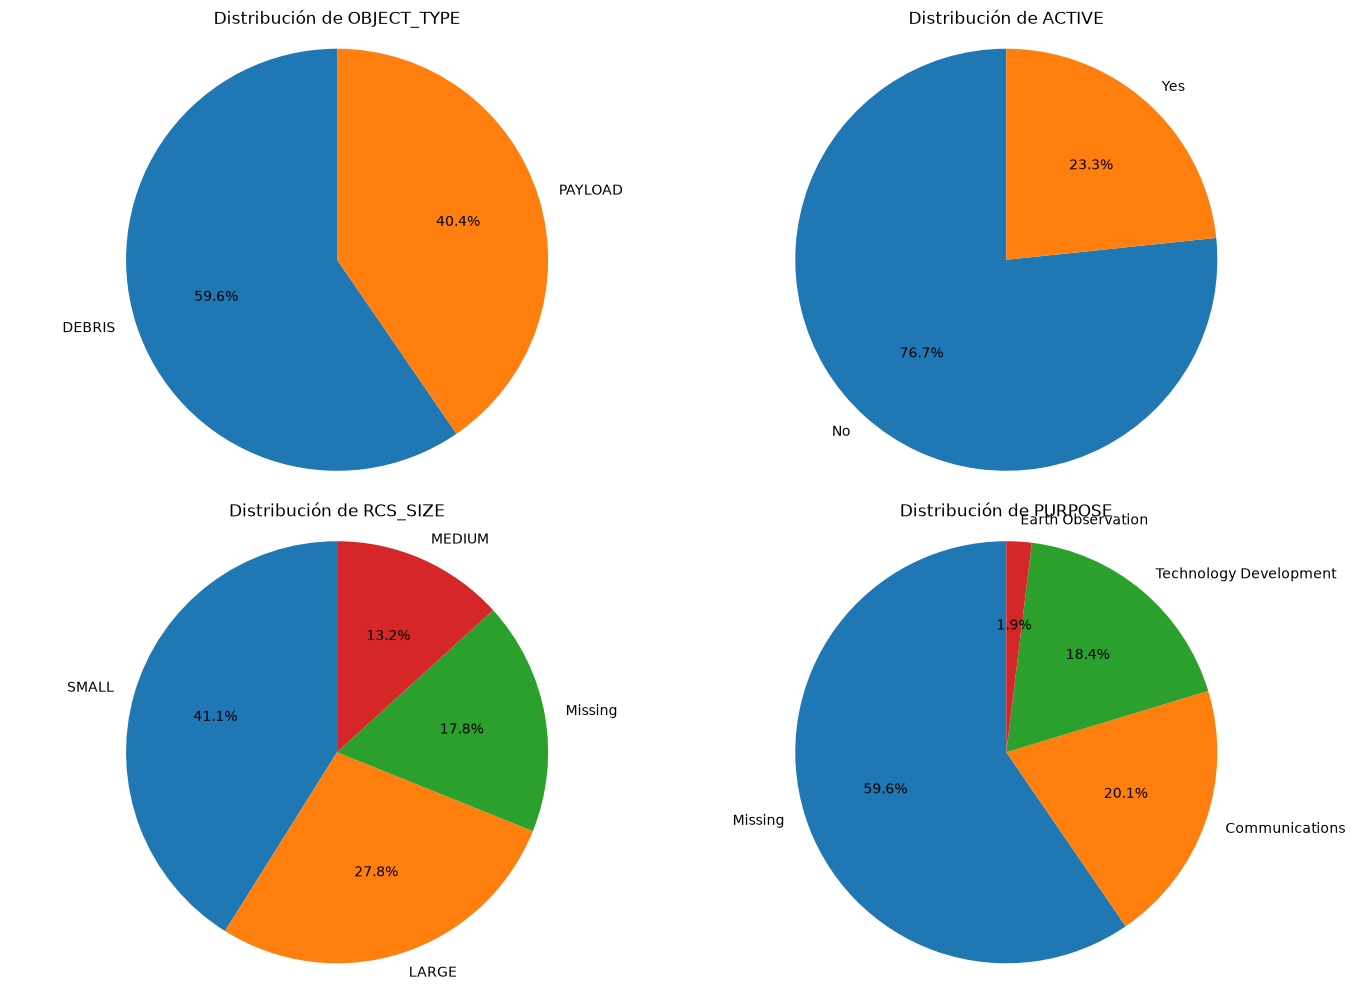

In [26]:
# Categorical variables to visualize
categorical_cols = ["OBJECT_TYPE", "ACTIVE", "RCS_SIZE", "PURPOSE"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.ravel(), categorical_cols):
    
    # Include missing values as an explicit category
    values = data[col].astype("string").fillna("Missing")
    counts = values.value_counts()
    
    ax.pie(
        counts,
        labels=counts.index,
        autopct="%1.1f%%",
        startangle=90
    )
    
    ax.set_title(f"Distribución de {col}")
    ax.axis("equal")

plt.tight_layout()
plt.show()

- `OBJECT_TYPE` tiene los objetos clasificados como `DEBRIS`, que representan aproximadamente el **59.57 %** de los registros, mientras que los objetos `PAYLOAD` representan el **40.43 %**. Esto indica que la base no está compuesta únicamente por satélites activos o misiones operativas, sino también por una proporción importante de objetos ya considerados desechos orbitales.

- La variable `ACTIVE` muestra un claro desbalance: aproximadamente el **76.65 %** de los objetos aparece clasificado como `No`, frente a un **23.35 %** clasificado como `Yes`. Este resultado es relevante porque `ACTIVE` será la variable objetivo en etapas posteriores de modelado. Así que más adelante será necesario considerar métricas de evaluación adecuadas para clases desbalanceadas.

- La variable `RCS_SIZE` muestra que la categoría más frecuente es `SMALL`, con **41.09 %** de los registros, seguida por `LARGE` (**27.82 %**) y `MEDIUM` (**13.25 %**). Sin embargo, también se observan los valores faltantes (`Missing`), con **17.85 %**, por lo que esta variable deberá utilizarse revisarse nuevamente en análisis posteriores.

- `PURPOSE` presenta una situación particular: la categoría `Missing` concentra el **59.57 %** de los registros, mientras que las observaciones disponibles se distribuyen principalmente entre `Communications` (**20.13 %**) y `Technology Development` (**18.37 %**), con una proporción mucho menor de `Earth Observation` (**1.93 %**). Podriamos decir que la variable tendrá que analizarse cuidadosamente por la relación entre valores faltantes y tipo de objeto. Podría ser posible que muchos desechos orbitales no tengan un propósito de misión identificado.

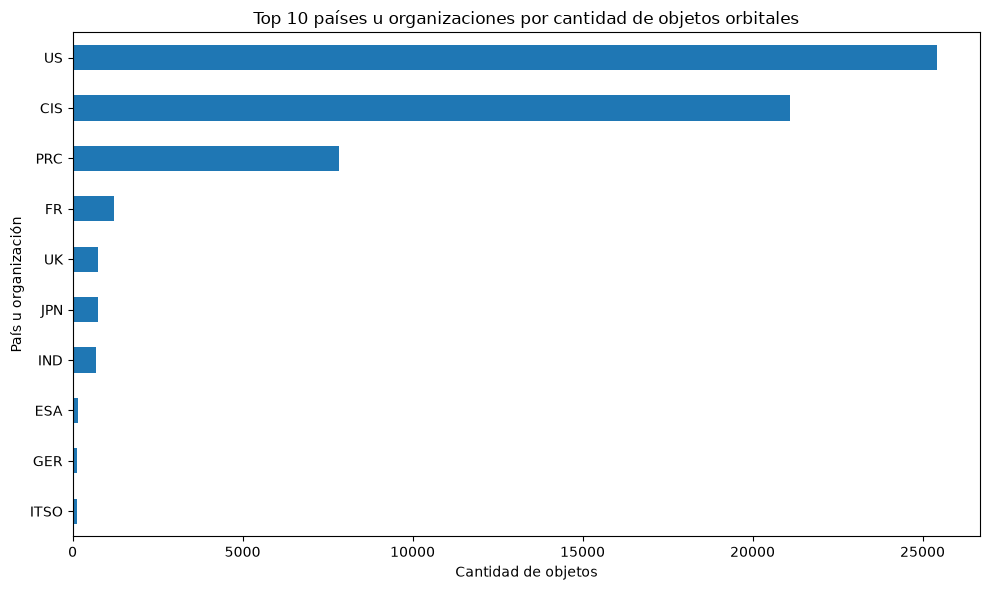

In [27]:
# Top 10 countries or organizations by number of orbital objects
top_countries = data["COUNTRY"].value_counts().head(10)

plt.figure(figsize=(10, 6))

top_countries.sort_values().plot(kind="barh")

plt.title("Top 10 países u organizaciones por cantidad de objetos orbitales")
plt.xlabel("Cantidad de objetos")
plt.ylabel("País u organización")

plt.tight_layout()
plt.show()

La distribución por país u organización muestra una fuerte concentración de los objetos orbitales en unos pocos. `US` presenta la mayor cantidad de registros, seguido por `CIS` y `PRC`, mientras que el resto de las categorías muestra una participación considerablemente menor.

En conjunto, estas tres categorías concentran aproximadamente el 90 % de los objetos del dataset, lo que evidencia una distribución altamente desigual de la población orbital según país u organización responsable. En análisis posteriores podremos estudiar si esta concentración se mantiene al diferenciar por tipo de objeto (`PAYLOAD` o `DEBRIS`), estado operativo (`ACTIVE`) y período de lanzamiento.

### Que conviene dejar registrado en esta etapa

- Describir que tipos de objetos dominan el dataset y si hay categorias claramente mayoritarias.
- Revisar si ACTIVE aparece balanceada o no, aun cuando en este notebook solo la miremos de forma descriptiva.
- Anotar por que estas proporciones pueden influir mas adelante en las decisiones de modelado y evaluacion.
- Si afirman que una categoria domina claramente o que existe desbalance, justificarlo con porcentajes, razones o algun contraste simple de proporciones.

## 4. Evolución temporal

El eje temporal es central para el problema porque permite ver como crece la actividad orbital a lo largo de los anos. Mirar la cantidad de objetos por año y su acumulado historico ayuda a dimensionar la escala del fenomeno y a detectar posibles cambios recientes en la dinamica de lanzamientos.

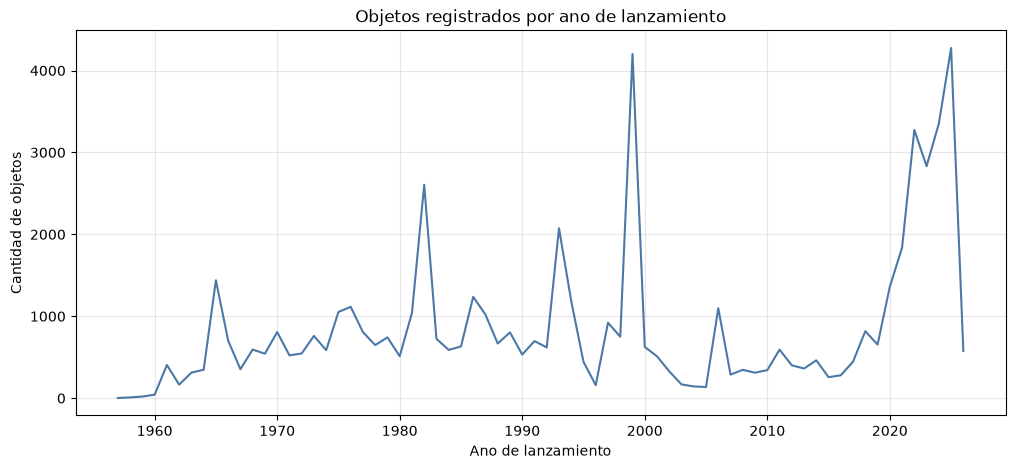

In [ ]:
launches_by_year = data.groupby("LAUNCH_YEAR").size()

fig, ax = plt.subplots(figsize=(12, 5))
launches_by_year.plot(ax=ax, color="#4C78A8")
ax.set_title("Objetos registrados por año de lanzamiento")
ax.set_xlabel("Ano de lanzamiento")
ax.set_ylabel("Cantidad de objetos")
ax.grid(True, alpha=0.3)
plt.show()

In [1]:
fig, ax = plt.subplots(figsize=(12, 5))
launches_by_year.cumsum().plot(ax=ax, color="#72B7B2")
ax.set_title("Acumulado historico de objetos registrados")
ax.set_xlabel("Año de lanzamiento")
ax.set_ylabel("Cantidad acumulada")
ax.grid(True, alpha=0.3)
plt.show()

NameError: name 'plt' is not defined

### Pistas para la interpretacion

- Identificar periodos de crecimiento acelerado o cambios notorios en la tendencia.
- Comparar el comportamiento reciente con las decadas anteriores para ver si cambia la escala del problema.
- Registrar hipótesis sobre posibles causas del crecimiento observado, siempre separando interpretacion de evidencia.
- Si sostienen que hubo un cambio en la tendencia entre periodos, respaldarlo con comparaciones de medias, medianas, tasas de crecimiento o el test que consideren adecuado.

## 5. Variables orbitales

Las variables orbitales pueden aportar informacion valiosa para entender en que condiciones se encuentran los objetos y como se distribuyen en distintas orbitas. En esta primera pasada las observamos de forma descriptiva; el tratamiento de outliers, escalado y transformaciones queda para los siguientes notebooks.

In [9]:
orbital_cols = ["PERIOD", "INCLINATION", "APOGEE", "PERIGEE"]
data[orbital_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
PERIOD,59236.00,162.94,620.07,0.00,89.54,94.11,100.43,95687.68
INCLINATION,59236.00,69.70,24.33,0.00,53.05,70.41,96.79,150.93
APOGEE,59236.00,2910.11,11600.38,0.00,280.00,483.00,835.00,638523.00
PERIGEE,59236.00,1623.48,6339.27,0.00,212.00,453.00,660.25,314973.00


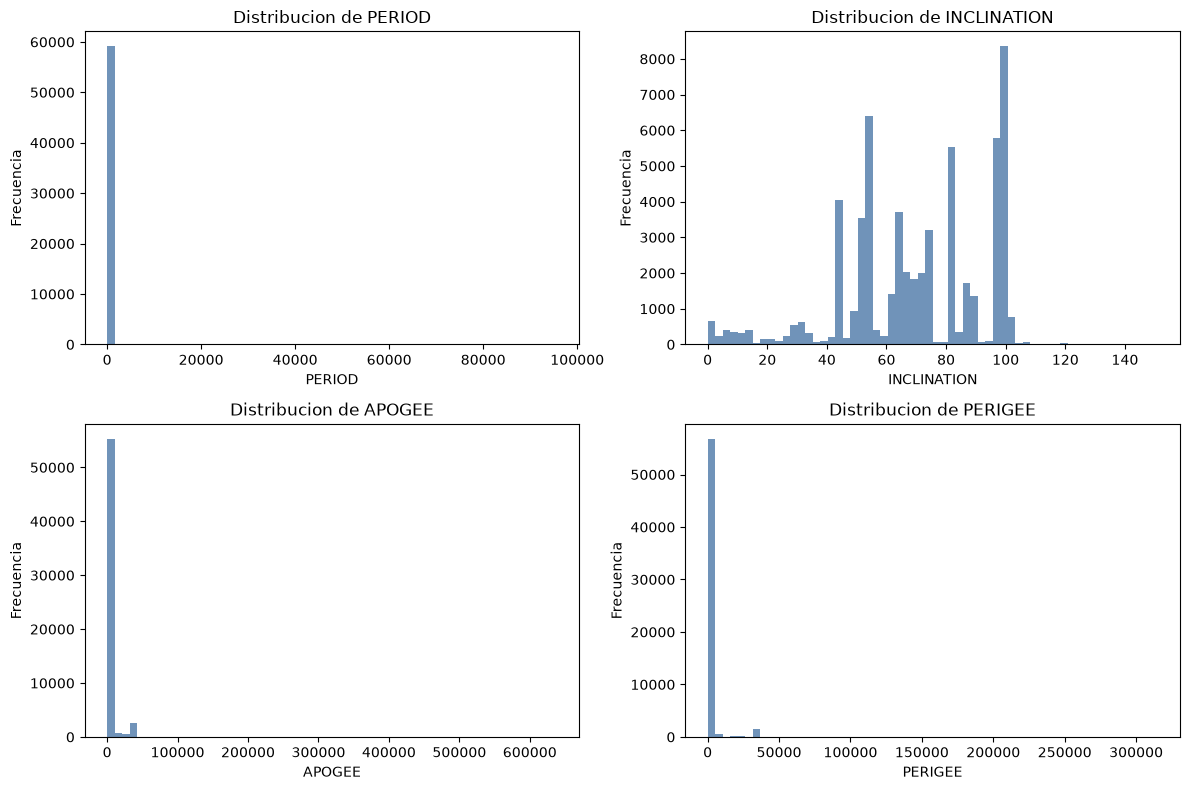

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.ravel(), ["PERIOD", "INCLINATION", "APOGEE", "PERIGEE"]):
    data[col].dropna().plot(kind="hist", bins=60, ax=ax, color="#4C78A8", alpha=0.8)
    ax.set_title(f"Distribucion de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

### Que observar en estas distribuciones

- Identificar distribuciones concentradas, sesgadas o con valores extremos evidentes.
- Senalar que variables parecen necesitar una revision mas cuidadosa de outliers o escalas.
- Registrar si alguna variable orbital sugiere una segmentacion natural que pueda explorarse despues.

## 6. Pistas para la curacion de datos

Aunque todavia no hacemos una curacion formal, este punto sirve para dejar anotadas senales que ya aparecen en la inspeccion inicial.

- Elegir columnas con faltantes relevantes y discutir si esas ausencias parecen esperables o problematicas.
- Separar posibles errores de carga de ausencias propias del dominio o de la forma en que se registra cada objeto.
- Registrar decisiones pendientes para el notebook de analisis exploratorio y curacion.
- Indicar tambien que variables podrian requerir transformaciones o chequeos adicionales antes de aplicar tests estadisticos.

## 7. Entregables esperados

Al finalizar este notebook, el grupo deberia poder entregar:

- Una descripcion breve del dataset y de las variables mas importantes para el objetivo del proyecto.
- Visualizaciones interpretadas, no solo generadas, que ayuden a contar una historia del conjunto de datos.
- Un analisis temporal de lanzamientos y crecimiento acumulado de objetos.
- Una lectura descriptiva de las principales variables orbitales.
- Al menos dos hipotesis explicitamente formuladas y contrastadas con algun indicador estadistico o test adecuado.
- Una lista de problemas de datos, faltantes o decisiones pendientes para el proximo notebook.
- Un conjunto inicial de hipotesis para validar mediante curacion, ingenieria de variables o modelado.

## 8. Puente hacia los proximos notebooks

Para el notebook de **analisis exploratorio y curacion de datos**, conviene dejar identificadas las columnas que requieren revision: fechas, faltantes, valores extremos, categorias poco frecuentes, variables redundantes, codificacion de PURPOSE y posible definicion de variables derivadas. Tambien es importante dejar asentado que supuestos habria que revisar antes de aplicar pruebas estadisticas con mayor formalidad.

Para el notebook de **aprendizaje supervisado, no supervisado, o ambos**, la idea es dejar planteadas hipotesis predictivas o de segmentacion: por ejemplo, si LAUNCH_YEAR, OBJECT_TYPE, COUNTRY, PURPOSE, RCS_SIZE o los parametros orbitales parecen asociarse con ACTIVE o con grupos naturales de objetos. En esta entrega, esas asociaciones deberian empezar a justificarse no solo con graficos sino tambien con evidencia estadistica basica.